# Diabetes Challenge

Your task today is to **analyze** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has Diabetes or not.

## Task:
- Load the data from the database. The schema is called `diabetes`. To connect to the database you need to copy the `.env` file from the visualization or hands-on-ml repository into this repo. Explore the database, try to establish what the relationships between the tables are (1-1, 1-N, N-M). Explain to yourself and the group what data do you see and whether it makes sense. What JOINs are appropriate to use and why? 
- Use at least two different classification algorithms we have learned so far to predict Diabetes patients. 
- Discuss before you start with the modeling process which **evaluation metric** you choose and explain why.
- Implement a GridSearchCV or RandomizedSearchCV to tune the hyperparameters of your model.
- **Optional:** If you have time at the end, try to use sklearn's pipline module to encapsulate all the steps into a pipeline.

Don't forget to split your data in train and test set. And analyze your final model on the test data. It might also be necessary to scale your data in order to improve the performance of some of the models.


## Helpful links and advise:
- [sklearn documentation on hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)
- It might be helpful to check some sources on how to deal with imbalanced data. 
    * [8 Tactics to Combat Imbalanced Classes](https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/)
    * [Random-Oversampling/Undersampling](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)


# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|Blood values on two separate dates allows to track metabolic changes and progression toward Type 2 diabetes|
|:------------|:------------|:------------|
|Pregnancies|Number of times pregnant||
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|Stable Normal (<140 mg/dL);Increasing Trend (140 to 199 mg/dL) Progressing into Impaired Glucose Tolerance (Prediabetes); Spike over 200 mg/dL crosses the threshold for a clinical diagnosis of Type 2 Diabetes|
|BloodPressure|Diastolic blood pressure (mm Hg)|rising trend indicates developing hypertension, particularly Diabetic Kidney Disease|
|SkinThickness|Triceps skin fold thickness (mm)||
|Insulin|2-Hour serum insulin (mu U/ml)|High/Rising Insulin while normal or slightly elevated glucose: worsening Insulin Resistance; Falling Insulin with High Glucose: Pancreatic Beta-Cell Exhaustion|
|BMI|Body mass index (weight in kg/(height in m)^2)||
|DiabetesPedigreeFunction| Diabetes pedigree function||
|Age| Age (years)||
|Outcome|Class variable (0 or 1) ||

# Imports

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)

# eda and visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
#sns.set_theme(style='whitegrid', palette="muted") #, context='notebook'

# building pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer

# models
from sklearn.model_selection import train_test_split, cross_validate, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor

# performance analisys 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, mean_absolute_error, mean_squared_error

# fetching data
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Feel free to add all the libraries you need

# Fetch data

In [3]:
# Read database string from .env file (you need to create this file and fill in the values)
load_dotenv()

DB_STRING = os.getenv("DB_STRING")

if DB_STRING is None:
    raise ValueError("DB_STRING environment variable is not set")

db = create_engine(DB_STRING)

In [4]:
# Define query to download
query_string = """set SCHEMA 'diabetes';
select p."Age" as age, p.pregnancies as preg, p.bmi, s.skinthickness as skin, md_1.insulin_1 as ins1, md_1.glucose_1 as glu1, md_1.bloodpressure_1 as bld1, md_2.insulin_2 as ins2, md_2.glucose_2 as glu2, md_2.bloodpressure_2 as bld2, po.diabetespedigreefunction as ped, po.outcome from
patient p
join
	(SELECT patientid as patientid_1, insulin as insulin_1, glucose as glucose_1, bloodpressure as bloodpressure_1
	FROM blood_metrics bm1
	where measurement_date = '2022-12-01') md_1
on p.id = md_1.patientid_1
join
	(select patientid as patientid_2, insulin as insulin_2, glucose as glucose_2, bloodpressure as bloodpressure_2
	FROM blood_metrics bm2
	where measurement_date = '2022-12-13') md_2
on p.id = md_2.patientid_2
left join pedigree_outcome po
on p.id = po.patientid
left join skin s
on p.id = s.patientid"""
# fetch with pandas
df_sqlalchemy = pd.read_sql(query_string, db)
#df_sqlalchemy_with_drop = df_sqlalchemy.drop(["id", "other_id"], axis=1)
# Save dataframe as .csv file
df_sqlalchemy.to_csv("data/patients.csv", index=False)
db.dispose() # Closes all connections in the pool
# Import data
df = pd.read_csv("data/patients.csv")

In [5]:
#EDA: check target values, missing values, unique values
print('Target value count')
print(df["outcome"].value_counts())

# Missing values
print()
print('empty values:')
print(df.isnull().sum().sort_values(ascending=False))

print()
print('unique values:')
print(df.nunique())
print(df.info())





Target value count
outcome
0    500
1    268
Name: count, dtype: int64

empty values:
age        0
preg       0
bmi        0
skin       0
ins1       0
glu1       0
bld1       0
ins2       0
glu2       0
bld2       0
ped        0
outcome    0
dtype: int64

unique values:
age         52
preg        17
bmi        248
skin        51
ins1       101
glu1       196
bld1       123
ins2       186
glu2       136
bld2        47
ped        517
outcome      2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      768 non-null    int64  
 1   preg     768 non-null    int64  
 2   bmi      768 non-null    float64
 3   skin     768 non-null    int64  
 4   ins1     768 non-null    int64  
 5   glu1     768 non-null    int64  
 6   bld1     768 non-null    int64  
 7   ins2     768 non-null    int64  
 8   glu2     768 non-null    int64  
 9   bld2     768 non-nu

In [6]:
print(df["age"].describe())
print()
print(df["bmi"].describe())

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: age, dtype: float64

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: bmi, dtype: float64


In [7]:
# age bins will be usefull for imputation of 0 values in other features
# The age variable is strongly right-skewed, meaning most of the women [due to pregnancy feature, assume all are women]
# in the study are concentrated in the younger brackets. Based on the statistics: define bin edges
# <30: Captures young adults and early-onset metabolic changes.
#   patients start at age 21, and the median age of individuals is roughly 29
# 30–50: Represents the middle-aged cohort.
#   here diabetes risk sharply escalates due to cumulative lifestyle and metabolic factors.
# >50: Reflects older adults with long-term exposure to risk factors and higher rates of diagnosed complications
age_bins = pd.cut(
    df["age"],
    bins=[0, 30, 50, float('inf')],  # float('inf') for ≥ 50
    labels=['early-onset', 'lifestyle and metabolic', 'long-term exposure'],
    right=False)
print(age_bins)
# Add to DataFrame if needed
df['age_bins'] = age_bins


0           long-term exposure
1      lifestyle and metabolic
2      lifestyle and metabolic
3                  early-onset
4      lifestyle and metabolic
                ...           
763         long-term exposure
764                early-onset
765    lifestyle and metabolic
766    lifestyle and metabolic
767                early-onset
Name: age, Length: 768, dtype: category
Categories (3, str): ['early-onset' < 'lifestyle and metabolic' < 'long-term exposure']


In [8]:
# There are 4 primary BMI bins considered universally meaningful for basic public health screening, this should do with regard to the short exercise time
# Define bin edges (must include outer edges to cover all values)
def add_bmi_category(dataframe, bmi_col='bmi'):
    """Add a 'bmi_category' column to the dataframe based on BMI values."""
    df = dataframe.copy()
    df['bmi_category'] = pd.cut(
        df[bmi_col],
        bins=[0, 18.5, 25, 30, float('inf')],
        labels=['Underweight', 'Healthy Weight', 'Overweight', 'Obesity'],
        right=False
    )
    return df

In [9]:
#add_bmi_category(df)
df = add_bmi_category(df)
df['bmi_category']

0             Obesity
1          Overweight
2      Healthy Weight
3          Overweight
4             Obesity
            ...      
763           Obesity
764           Obesity
765        Overweight
766           Obesity
767           Obesity
Name: bmi_category, Length: 768, dtype: category
Categories (4, str): ['Underweight' < 'Healthy Weight' < 'Overweight' < 'Obesity']

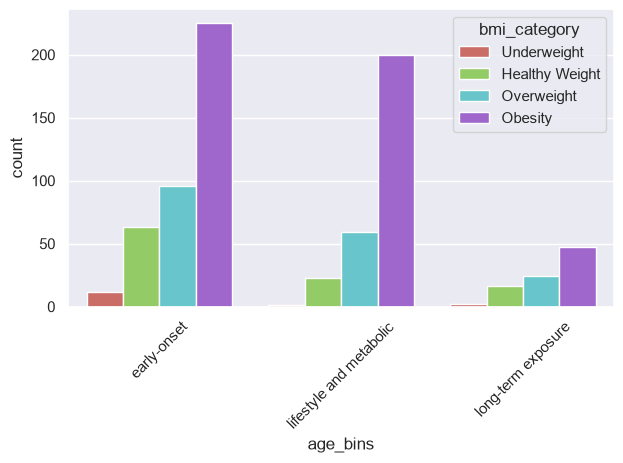

In [10]:
# bmi and age
sns.countplot(x="age_bins", data=df, hue="bmi_category", palette="hls")
plt.xticks(rotation=45)  # or 90 for vertical
plt.tight_layout()  # prevents label cutoff
plt.show()

In [11]:
# Bad data where 0 is not acceptable
# a value of 0 on either date for Glucose, Insulin, or Blood Pressure, this represents a missing data point or an unrecorded test, rather than a literal medical value
#bad_blood_data = df[df[['ins1', 'ins2', 'glu1', 'glu2', 'bld1', 'bld2']].isin([0]).any(axis=1)]
columns_to_check = ['bmi', 'skin', 'ins1', 'ins2', 'glu1', 'glu2', 'bld1', 'bld2']
bad_blood_data = df[df[columns_to_check].isin([0]).any(axis=1)]

print()
print('Bad data for BMI, Skin, Insulin, Glocose or Blood pressure')
print(bad_blood_data)
print('Zero_Count')
print(df[columns_to_check].isin([0]).sum())

# Dealing with 0 values in continous data:

#heartrate_medians = df.groupby(["sex", "age_bins"])["maximum_heartrate_achieved"].median().to_dict()
#print(heartrate_medians)


Bad data for BMI, Skin, Insulin, Glocose or Blood pressure
     age  preg   bmi  skin  ins1  glu1  bld1  ins2  glu2  bld2    ped  \
0     50     6  33.6    35    80   172   117     0   148    72  0.627   
1     31     1  26.6    29    80    54    93     0    85    66  0.351   
2     32     8  23.3     0     1   168   100     0   183    64  0.672   
5     30     5  25.6     0    10   112    39     0   116    74  0.201   
7     29    10  35.3     0    14   101    39     0   115     0  0.134   
..   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...    ...   
761   43     9  44.0    31    59   100    17     0   170    74  0.403   
762   33     9  22.5     0    74     1    98     0    89    62  0.142   
764   27     2  36.8    27     6    23    96     0   122    70  0.340   
766   47     1  30.1     0    65   100    58     0   126    60  0.349   
767   23     1  30.4    31    55   106   108     0    93    70  0.315   

     outcome                 age_bins    bmi_category  
0      

# EDA plan
## Missing Data
- First after splitting: impute missing bmi (11 rows, about 1,43%) = mean by age_bin and pregnancy
- create new sepatared bmi_bins to keep clean test data
### skinthickness
In the Pima Indians Diabetes dataset, missing values for SkinThickness are recorded as biologically impossible zero values, affecting 227 out of 768 observations (about 30%)
- shares a moderate positive correlation (around 0.55) with Body Mass Index (BMI), meaning BMI is often used to help estimate or impute missing skin thickness values.
- Imputation: Fill missing values using predictive imputation method KNN leveraging the strong correlation with BMI.
### blood_metrics
In the context of medical longitudinal studies or data analysis involving the Pima Indians Diabetes Dataset, looking at blood values on two separate dates allows you to track metabolic changes and progression toward Type 2 diabetes.
Plasma Glucose Concentration:
- Plasma Glucose Concentration
- Serum Insulin
- Diastolic Blood Pressure

In [12]:
# Test split: keep track of changes from here
print("df shape:", df.shape)
y = df ["outcome"] # this is the data wo 50x missing 
X = df.drop(["outcome", "bmi_category"], axis=1) # remove bmi_category which was not clean
print("X shape:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25) # X_train df is used for further EDA
print("X_train shape:", X_train.shape)
#df_train = pd.concat([X_train, y_train], axis=1, ignore_index=False)

df shape: (768, 14)
X shape: (768, 12)
X_train shape: (537, 12)


In [13]:
# impute bmi
# Calculate median bmi per age and pregnancy
bmi_medians = X_train.groupby(["age", "preg"])["bmi"].median().to_dict()  # same values used for test
print(bmi_medians)

# find null values in the bmi feature, and for each null assign a bmi value according to the average age of patients by number of pregn
def bmi_approx(cols):
    bmi = cols["age"]
    age = cols["age"]
    preg = cols["preg"]

    if pd.isnull(bmi):
        return bmi_medians[age, preg]
    else:
        return bmi

{(21, 0): 28.6, (21, 1): 28.6, (21, 2): 28.2, (21, 3): 42.7, (21, 4): 24.7, (22, 0): 30.8, (22, 1): 27.5, (22, 2): 27.3, (22, 3): 23.950000000000003, (22, 4): 44.0, (22, 8): 28.4, (23, 0): 34.9, (23, 1): 30.1, (23, 2): 28.9, (23, 3): 22.9, (23, 4): 34.0, (23, 6): 28.7, (24, 0): 42.45, (24, 1): 30.8, (24, 2): 38.099999999999994, (24, 3): 31.049999999999997, (24, 4): 33.2, (24, 5): 30.2, (25, 0): 36.2, (25, 1): 24.700000000000003, (25, 2): 28.9, (25, 3): 30.7, (25, 5): 33.7, (26, 0): 41.900000000000006, (26, 1): 41.4, (26, 2): 40.3, (26, 3): 32.0, (26, 4): 43.6, (26, 6): 0.0, (27, 0): 29.3, (27, 1): 22.4, (27, 2): 28.0, (27, 3): 32.4, (27, 4): 28.9, (27, 5): 45.7, (27, 6): 35.55, (28, 0): 39.599999999999994, (28, 1): 39.0, (28, 2): 30.2, (28, 3): 31.6, (28, 4): 34.5, (28, 5): 35.5, (28, 6): 23.7, (29, 0): 38.8, (29, 1): 32.0, (29, 2): 28.0, (29, 3): 29.45, (29, 4): 34.8, (29, 5): 35.3, (29, 6): 27.6, (29, 7): 26.5, (30, 0): 32.3, (30, 1): 31.450000000000003, (30, 2): 32.9, (30, 3): 34.5,

In [14]:
# check results
if X_train.loc[X_train["bmi"].isin([0]), "age"].isin([0]).any():
    raise ValueError("Some rows with missing bmi also have missing age, so bmi imputation by age cannot proceed.")
else:
    X_train["bmi"] = X_train[["bmi", "age", "preg"]].apply(bmi_approx, axis=1)
X_train.isin([0]).sum()

age           0
preg         80
bmi           0
skin        160
ins1          3
glu1          4
bld1          1
ins2        262
glu2          4
bld2         23
ped           0
age_bins      0
dtype: int64

In [15]:
# TEST: Replace missing values in bmi column with median
if X_test.loc[X_test["bmi"].isin([0]), "age"].isin([0]).any():
    raise ValueError("Some rows with missing bmi also have missing age, so bmi imputation by age cannot proceed.")
else:
    X_test["bmi"] = X_test[["bmi", "age", "preg"]].apply(bmi_approx, axis=1)
X_test.isin([0]).sum()

age           0
preg         31
bmi           0
skin         67
ins1          3
glu1          0
bld1          0
ins2        112
glu2          1
bld2         12
ped           0
age_bins      0
dtype: int64

In [16]:
# add back bmi_category
X_train = add_bmi_category(X_train)
X_test = add_bmi_category(X_train)

In [17]:
# convert fake 0 to NaN for the rest of columns
columns_to_convert = ['skin', 'ins1', 'ins2', 'glu1', 'glu2', 'bld1', 'bld2']
X_train[columns_to_convert] = X_train[columns_to_convert].replace(0, np.nan)
X_test[columns_to_convert] = X_test[columns_to_convert].replace(0, np.nan)

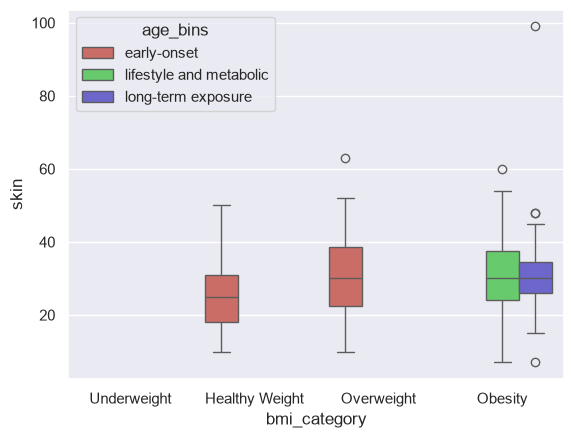

In [18]:
# Display skin per age and bmi
#print(X_train.groupby(by=["preg"])["age_bin"].describe())
sns.boxplot(x="bmi_category", y="skin", data=X_train, hue="age_bins", palette="hls");


<Axes: >

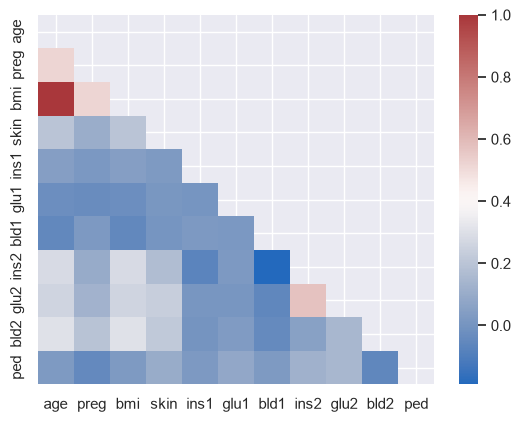

In [19]:
# Compute correlations to find dependent features to drop
correlations = X_train.drop(["age_bins", "bmi_category"], axis=1).corr() # age_bins is a category
# Keep only the strictly lower triangle (upper triangle and diagonal become NaN)
lower_corr = correlations.where(np.tril(np.ones(correlations.shape), k=-1).astype(bool))
# Draw the heatmap
sns.heatmap(lower_corr, cmap='vlag')

Missing skin values remaining: 160


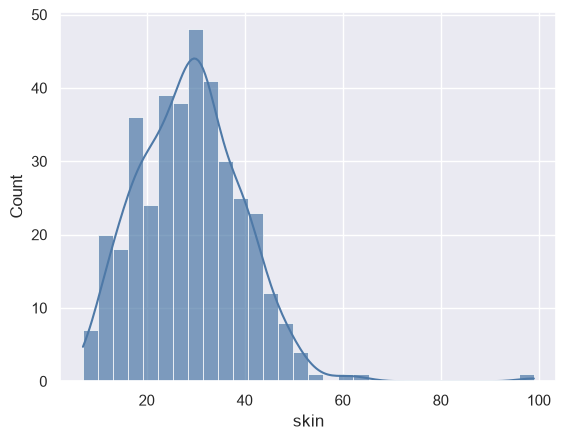

In [20]:
# dealing with skin data
sns.histplot(data=X_train, x="skin", kde=True, alpha=0.7, color="#4e79a7", bins=30, linewidth=0.5, label="Original Data")
print(f"Missing skin values remaining: {X_train['skin'].isna().sum()}")
X_train_orig = X_train.copy()

In [21]:
# imputing skin data using a knn model

# define the features and separate rows with existing values from rows with missing values 
skin_imputer_features = ['age', 'preg', 'bmi']
working_df = X_train[['age', 'preg', 'bmi', 'skin']]
skin_present = working_df[working_df['skin'].notna()]
skin_missing = working_df[working_df['skin'].isna()]

# predictor matrices for the two groups
X_present = skin_present[skin_imputer_features].to_numpy()
X_missing = skin_missing[skin_imputer_features].to_numpy()

# scaler object for KNN (KNN uses distance, so a larger-scale feature can dominate just because of its units, not because it’s more informative.)
scaler = StandardScaler()
scaler.fit(X_present)
X_present_scaled = scaler.transform(X_present)
X_missing_scaled = scaler.transform(X_missing)

# KNN regressor - predict skin (numeric) from age, preg, bmi
knn = KNeighborsRegressor(n_neighbors=9)  # k=5 is a common default

# known-row data:
knn.fit(X_present_scaled, skin_present['skin']) # y_present = skin_present

# 4. predict missing skin values:
skin_imputed = knn.predict(X_missing_scaled)

# place predictions back into the original dataframe
working_df.loc[skin_missing.index, 'skin'] = skin_imputed # skin_missing.index points to the rows that were missing

# --- Verify ---
print(f"Missing skin values remaining: {working_df['skin'].isna().sum()}")

# finally add imputed data to the train data
X_train['skin'] = working_df['skin']


Missing skin values remaining: 0


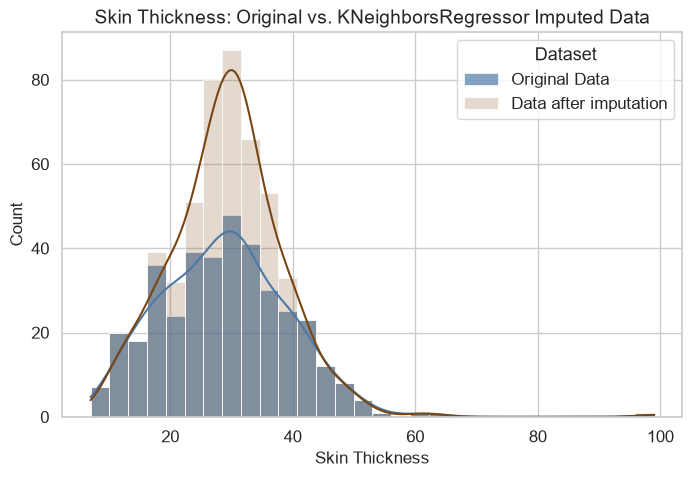

In [22]:
# Visualize imputed data
# Set a clean visual style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Create the distribution plot
plt.figure(figsize=(8, 5))
sns.histplot(data=X_train_orig, x="skin", kde=True, alpha=0.7, color="#4e79a7", bins=30, linewidth=0.5, label="Original Data")
sns.histplot(data=X_train, x="skin", kde=True, alpha=0.2, color="#784513", bins=30, linewidth=0.5, label="Data after imputation")

plt.legend(title="Dataset", frameon=True, fancybox=True, loc="upper right")

# Add clear labels
plt.title("Skin Thickness: Original vs. KNeighborsRegressor Imputed Data", fontsize=14)
plt.xlabel("Skin Thickness", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()


In [23]:
# repeat for X_test
working_df_test = X_test[['age', 'preg', 'bmi', 'skin']]
skin_missing_test = working_df_test[working_df_test['skin'].isna()]
X_test_missing = skin_missing_test[skin_imputer_features].to_numpy()
X_test_missing_scaled = scaler.transform(X_test_missing)
skin_imputed_test = knn.predict(X_test_missing_scaled)
working_df_test.loc[skin_missing_test.index, 'skin'] = skin_imputed_test

# --- Verify ---

X_test_orig = X_test.copy() # keep for performance test

print(f"Missing skin values remaining: {working_df_test['skin'].isna().sum()}")
X_test['skin'] = working_df_test['skin']
X_test.isna().sum()


Missing skin values remaining: 0


age               0
preg              0
bmi               0
skin              0
ins1              3
glu1              4
bld1              1
ins2            262
glu2              4
bld2             23
ped               0
age_bins          0
bmi_category      0
dtype: int64

## Performance check SimpleImputer vs KNN Imputation: was it worth the effort?
KNN Imputer uses correlation with age, preg, bmi features
SimpleImputer: Uses a single statistic (median) from training data
### Why median?
Skin thickness distribution shows skewness, see histogram.


In [24]:
# Performance test split:
#print("df shape:", df.shape)

skin_present_perf = X_train_orig[X_train_orig['skin'].notna()]
working_df_perf = skin_present_perf[['age', 'preg', 'bmi', 'skin']]
y_perf = working_df_perf [["skin"]]
X_perf = working_df_perf.drop(["skin"], axis=1)
#print("X shape:", X_perf.shape)
X_train_perf, X_test_perf, y_train_perf, y_test_perf = train_test_split(X_perf, y_perf, test_size=0.3, random_state=25)
#print("X_train shape:", X_train_perf.shape)
#print("y_train shape:", y_train_perf.shape)
#df_train = pd.concat([X_train, y_train], axis=1, ignore_index=False)

y_test_perf_hide = y_test_perf.copy() # this is the original data to be hidden
y_test_perf_hide[["skin"]] = np.nan # hiding data

print("y_test_perf_hide shape:", y_test_perf_hide.shape)


y_test_perf_hide shape: (114, 1)


In [ ]:
# performance of SimpleImputer
#simple_imputer = SimpleImputer(strategy='mean') #median
simple_imputer = SimpleImputer(strategy='median') #median 
simple_imputer.fit(y_train_perf[['skin']])
y_test_perf_pred = simple_imputer.transform(y_test_perf_hide[['skin']])
#print("y_test_perf_pred shape:", y_test_perf_pred.shape)
y_test_perf_pred = y_test_perf_pred.flatten()
#print("y_test_perf_pred shape:", y_test_perf_pred.shape)
mae_simple = mean_absolute_error(y_test_perf, y_test_perf_pred)
rmse_simple = np.sqrt(mean_squared_error(y_test_perf, y_test_perf_pred))
print(f"MAE SimpleImputer: {mae_simple:.4f} | RMSE SimpleImputer: {rmse_simple:.4f}")


MAE SimpleImputer: 7.5000 | RMSE SimpleImputer: 9.2286


In [26]:
# performance of KNeighborsRegressor
scaler_perf = StandardScaler()
scaler_perf.fit(X_train_perf)
X_train_perf_scaled = scaler_perf.transform(X_train_perf)
X_test_perf_scaled = scaler_perf.transform(X_test_perf)
knn_perf = KNeighborsRegressor(n_neighbors=9)  # k=5 is a common default
knn_perf.fit(X_train_perf_scaled, y_train_perf['skin']) # y_train_perf = skin_present
y_test_knn_perf_pred = knn_perf.predict(X_test_perf_scaled)
mae_knn = mean_absolute_error(y_test_perf, y_test_knn_perf_pred)
rmse_knn = np.sqrt(mean_squared_error(y_test_perf, y_test_knn_perf_pred))
print(f"MAE KNeighborsRegressor: {mae_knn:.4f} | RMSE KNeighborsRegressor: {rmse_knn:.4f}")

MAE KNeighborsRegressor: 7.0712 | RMSE KNeighborsRegressor: 8.8613


In [27]:
# performance check

def percent_improvement(mae_simple, rmse_simple, mae_knn, rmse_knn):
    mae_improvement = (mae_simple - mae_knn) / mae_simple * 100
    rmse_improvement = (rmse_simple - rmse_knn) / rmse_simple * 100
    
    return {
        'mae_improvement_%': mae_improvement,
        'rmse_improvement_%': rmse_improvement
    }

percent_improvement(mae_simple, rmse_simple, mae_knn, rmse_knn)

{'mae_improvement_%': 5.717998700454826,
 'rmse_improvement_%': np.float64(3.9793369761590216)}

In [28]:
# using pipeline for other columns except ins2
impute_rest = ['ins1', 'glu1', 'bld1', 'glu2', 'bld2']
rest_preprocess = Pipeline([("imputer", SimpleImputer(strategy="median"))])
# Fit the imputer on the training data
rest_preprocess.fit(X_train[impute_rest])
# Impute the training and test data and assign back to the original DataFrames
X_train.loc[:, impute_rest] = rest_preprocess.transform(X_train[impute_rest])
X_test.loc[:, impute_rest] = rest_preprocess.transform(X_test[impute_rest])

# Verify
print(f"Missing values remaining in train: {X_train[impute_rest].isna().sum()}")
print(f"Missing values remaining in test: {X_test[impute_rest].isna().sum()}")

Missing values remaining in train: ins1    0
glu1    0
bld1    0
glu2    0
bld2    0
dtype: int64
Missing values remaining in test: ins1    0
glu1    0
bld1    0
glu2    0
bld2    0
dtype: int64


In [ ]:
model = Pipeline([
    ("preprocessor", rest_preprocess),
    ("model", (max_depth=5, random_state=42))
    ])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be us

In [ ]:
model = Pipeline([
    ("preprocessor", rest_preprocess),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
    ])

cv = ShuffleSplit(n_splits=20, test_size=25, random_state=17)
cv_results = cross_validate(
    estimator=model,
    X=data,
    y=target,
    cv=cv,
    scoring=["mae", "rmse", mean_absolute_error, np.sqrt(mean_squared_error)],
    return_estimator=True,
    n_jobs=-1
    )

cv_results["test_recall"]

In [ ]:
# dealing with ins2
